# Introduction

This Notebook introduces Gemma 4:E2B (it).

In a [previous Notebook](https://www.kaggle.com/code/gpreda/test-gemma-4-e2b-on-cpu), we just tested it on CPU.

Here we will run more tests, using Kaggle GPUs free tier.

## About Gemma

Recently Gemma 4 was released. Their capabilities include OCR, speech-to-text, object detection. They also support text-only, multimodal function calling, as well as reasoning, code completion, and correction.

Here are the features of each model:

* Gemma 4 E2B — has a context window of 128K. Parameter size is 2.3B effective, 5.1B with embeddings.
* Gemma 4 E4B — has a context window of 128K. Parameter size is 4.5B effective, 8B with embeddings.
* Gemma 4 26B — mixture of experts with 4B activated/26 total parameters. Context window in 256K.
* Gemma 4 31B — it is a 31B dense model, with context window 256K.
All models have both base and it versions. We will use Ollama on a local machine to run Gemma 4 E2B.


<center><img src="https://storage.googleapis.com/gweb-uniblog-publish-prod/images/gemma-4_blog_keyword_meta-dark.width-1300.png" width=600></center>



# Upgrade transformers

In [1]:
!pip install -U transformers  -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 103.9 MB/s eta 0:00:00


# Import packages

In [2]:
from time import time
from IPython.display import Markdown
import requests
from PIL import Image
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Initialize model

In [3]:
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e2b-it")

processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

# Test with text input

In [4]:
messages = [
    {"role": "system", "content": "You are a helpful assistant that specializes in answering shortly to any question."},
    {"role": "user", "content": "When we first walked on the Moon?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 12.02


Let's display the output more user friendly.

In [5]:
output = processor.parse_response(response)

# Format the output

In [6]:
def colorize_text(text):
    for word, color in zip(["Thinking", "Thinking Process", "Response", "Total time"], ["blue", "red", "green", "magenta"]):
        text = text.replace(f"{word}:", f"\n\n**<font color='{color}'>{word}:</font>**")
    return text
    
def display_response(output, total_time):
    if output.get('thinking'):
        display(Markdown(f"<font color='green'>Thinking</font>"))
        display(Markdown(colorize_text(output["thinking"])))
    if output.get('content'):
        display(Markdown(f"<font color='blue'>Response</font>"))
        display(Markdown(output["content"]))
    display(Markdown(colorize_text(f"Total time: {total_time} sec.")))

In [7]:
display_response(output, total_time)

<font color='green'>Thinking</font>



**<font color='red'>Thinking Process:</font>**

1.  **Analyze the Request:** The user is asking, "When we first walked on the Moon?"
2.  **Identify the Core Event:** The first Moon landing.
3.  **Retrieve the Fact:** The first Moon landing (Apollo 11) occurred in July 1969.
4.  **Determine the Response Style:** The instruction states: "answer shortly to any question."
5.  **Formulate the Short Answer:** State the year/date directly.

6.  **Final Output Generation:** (July 1969)

<font color='blue'>Response</font>

July 20, 1969.



**<font color='magenta'>Total time:</font>** 12.02 sec.

# Multi-language tests


Let's first test with Romanian, my mother tongue.

In [8]:
messages = [
    {"role": "system", "content": "Ești un agent AI care răspunde în limba română."},
    {"role": "user", "content": "Cine a fost Nadia Comaneci?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

output = processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 78.67


In [9]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here's a thinking process to construct the answer about Nadia Comăneci:

1.  **Analyze the Request:** The user asked, "Cine a fost Nadia Comaneci?" (Who was Nadia Comăneci?). This requires a biographical summary focusing on her achievements and significance.

2.  **Identify Key Information about Nadia Comăneci:**
    *   **Who is she?** A Romanian gymnast.
    *   **When/Where?** Late 20th century (especially the 1970s/1980s).
    *   **What is she famous for?** Being the first gymnast to score a perfect 10.000 in the Olympics (Montreal 1976).
    *   **What was her impact?** She revolutionized gymnastics and brought global recognition to the sport.
    *   **Key Accomplishments:** Olympic medals, World Championship titles, setting new standards.

3.  **Structure the Answer (in Romanian):** A good biographical answer should have:
    *   **Introduction:** A direct statement of who she was.
    *   **Career Highlights:** Focusing on her major achievements (the perfect 10, international success).
    *   **Significance/Legacy:** Why she matters today.
    *   **Conclusion (Optional but good):** A summary statement.

4.  **Draft the Content (Iterative Translation/Refinement in Romanian):**

    *   *(Initial thought on Intro):* Nadia Comăneci a fost o gimnastică română foarte bună. (Too simple).
    *   *(Refinement):* Nadia Comăneci este una dintre cele mai mari și celebre gimnaste de toate timpurile. (Better).

    *   *(Focus on the defining moment):* Ea a făcut istorie când a primit nota perfectă. (Need to be more formal). -> Ea a făcut istorie prin obținerea primei note perfecte de 10.000 la Olimpiadă.

    *   *(Adding context):* Mentioning the era and the context of her success.

    *   *(Legacy):* Ea a inspirat mulți oameni.

5.  **Review and Polish (Ensuring fluent, appropriate Romanian):** (Self-Correction: Make sure the tone is respectful and highlights her historical importance.)

6.  **Final Output Generation:** (This leads to the detailed response provided below.) (The final response is comprehensive and addresses the "who" by detailing the "what" and "why.")

<font color='blue'>Response</font>

Nadia Comăneci este una dintre cele mai mari și celebre gimnaste de toate timpurile, recunoscută la nivel mondial pentru talentea sa excepțională și pentru momentul istoric pe care l-a marcat în sportul olimpic.

Iată o sinteză a celor mai importante aspecte ale vieții și carierei sale:

### 1. Cele Mai Importante Realizări

* **Nota Perfectă (10.000):** Cea mai mare realizare a sale este obținerea primei note perfecte de 10.000 la Olimpiade. Acest lucru a fost realizat la Jocurile Olimpice din Montreal în anul 1976, un moment care a marcat începutul unei ere noi în gimnastica.
* **Dominarea Internațională:** Comăneci a câștigat numeroase medii în competițiile internaționale, dominând scena gimnasticii și impunând un standard de perfecțiune extrem de ridicat.
* **Inovație:** Ea nu doar că a executat mișcări complexe, dar a schimbat modul în care se vedea și se evalua performanța în gimnastică, forțând judecătorii și concurenții să își îmbunătățească standardele.

### 2. Impactul și Moștenirea

Nadia Comăneci nu a fost doar o atletă de succes; ea a fost o **iconă**.

* **Inspirare:** Ea a inspirat generații de gimnaste din întreaga lume, demonstrând că disciplină, muncă intensă și perfecțiune pot duce la realizări de nivel olimpic.
* **Reprezentarea României:** A devenit un simbol național pentru România în cadrul sportului.
* **Revoluționarea Sportului:** Succesul ei a contribuit la profesionalizarea și la creșterea prestigioasei gimnastice la nivel mondial.

### Rezumat

**Nadia Comăneci a fost o gimnastică română care a definit o eră în sportul, fiind celebre pentru performanța sa impecabilă și pentru faptul



**<font color='magenta'>Total time:</font>** 78.67 sec.

Let's check as well with a question in French.

In [10]:
messages = [
    {"role": "system", "content": "Vous êtes un agent IA, répondez uniquement en français."},
    {"role": "user", "content": "Qui était Édith Piaf ?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

output = processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 55.91


In [11]:
display_response(output, total_time)

<font color='green'>Thinking</font>



**<font color='red'>Thinking Process:</font>**

1.  **Analyze the Request:** The user is asking "Who was Édith Piaf?" (Qui était Édith Piaf ?).
2.  **Identify the Subject:** Édith Piaf is a very famous, iconic French singer.
3.  **Determine Key Information Points:** To answer comprehensively, I need to cover:
    *   Who she was (identity, profession).
    *   Her significance (cultural impact, style).
    *   Her career highlights (music, style).
    *   Her legacy (why she is important).
4.  **Draft the Content (in French):**
    *   *Introduction:* Define her status (singer, icon).
    *   *Career:* Mention her origins, rise to fame, and musical style (passion, dramatic).
    *   *Key Achievements:* Mention her most famous songs or her impact on French music.
    *   *Legacy:* Describe her enduring influence (voice, emotion).
5.  **Refine and Format (Self-Correction/Enhancement):** Ensure the tone is respectful and informative. Structure the answer logically.

*(Self-Check against constraints: Respond only in French. Done.)*

6.  **Final Output Generation.** (This leads to the detailed response provided below.)

<font color='blue'>Response</font>

Édith Piaf (née Édith Giovanna Gassion) est l'une des figures les plus emblématiques et les plus célèbres de la chanson française et mondiale. Elle est considérée comme l'une des chanteuses les plus importantes de tous les temps.

Voici un aperçu de qui elle était :

### 1. Une Icône de la Chanson Française

Piaf est surtout connue pour sa voix puissante, pleine d'émotion et de passion, qui lui a permis de créer des chansons profondément personnelles et universelles. Elle est le symbole de la mélancolie, de la résistance et de la beauté brute de l'âme humaine.

### 2. Une Carrière Marquée

Sa carrière a débuté dans les années 1940 et a explosé dans les années 1950. Elle est devenue une véritable star, non seulement en France, mais aussi à l'international. Ses chansons parlaient souvent d'amour, de souffrance, de pauvreté et de vie quotidienne avec une intensité rare.

**Quelques exemples de son impact :**

*   **Style :** Son interprétation était théâtrale et viscérale, transformant chaque performance en une expérience émotionnelle intense pour le public.
*   **Chansons emblématiques :** Des titres comme *"La Vie en rose"*, *"Non, je ne regrette rien"*, et *"Sous le ciel de Paris"* sont devenus des classiques intemporels.

### 3. Un Symbole Culturel

Édith Piaf n'était pas seulement une chanteuse ; elle était une figure culturelle. Elle incarnait l'esprit de Paris, la passion française et une certaine forme de résilience face à l'adversité. Elle est devenue un symbole de la chanson française elle-même.

### En résumé

Édith Piaf était une artiste unique dont la force résidait dans sa capacité à transmettre, par sa voix, des émotions humaines profondes. Elle reste une icône immortelle, dont l'héritage musical et émotionnel continue d'inspirer des générations de chanteurs et d'amoureux de la musique.



**<font color='magenta'>Total time:</font>** 55.91 sec.

# Test with image


We will also test with an image.


<img src="https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png"></img>



In [12]:
image_url = "https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What you can see in this image?"}
        ]
    }
]
s_time = time()

text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=1024)

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
output = processor.parse_response(response)

e_time = time()
total_time = round(e_time - s_time, 2)

print(output)
print(f"Total time: {total_time}")

{'role': 'assistant', 'thinking': 'Here\'s a thinking process to arrive at the suggested description:\n\n1.  **Analyze the Request:** The user has provided an image and asked, "What you can see in this image?"\n\n2.  **Examine the Image (Initial Scan & Subject Identification):**\n    *   What is the main focus? A cow/bull.\n    *   What is the setting? A beach/shoreline.\n    *   What is the weather/mood? Sunny, bright, clear blue sky, clear water.\n\n3.  **Detailed Analysis of the Subject (The Cow):**\n    *   Color/Appearance: Brown/reddish-brown coat. White markings on the face/head.\n    *   Pose/Action: Standing, looking towards the camera/viewer.\n    *   Condition: Appears healthy.\n\n4.  **Detailed Analysis of the Background/Setting:**\n    *   Foreground: Light-colored sand (beach). A small amount of wet sand near the water\'s edge.\n    *   Midground: Clear, turquoise/blue ocean water (very shallow near the shore).\n    *   Background: A distant coastline or landmass (hills/m

Let's display the output nicely formated.

In [13]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here's a thinking process to arrive at the suggested description:

1.  **Analyze the Request:** The user has provided an image and asked, "What you can see in this image?"

2.  **Examine the Image (Initial Scan & Subject Identification):**
    *   What is the main focus? A cow/bull.
    *   What is the setting? A beach/shoreline.
    *   What is the weather/mood? Sunny, bright, clear blue sky, clear water.

3.  **Detailed Analysis of the Subject (The Cow):**
    *   Color/Appearance: Brown/reddish-brown coat. White markings on the face/head.
    *   Pose/Action: Standing, looking towards the camera/viewer.
    *   Condition: Appears healthy.

4.  **Detailed Analysis of the Background/Setting:**
    *   Foreground: Light-colored sand (beach). A small amount of wet sand near the water's edge.
    *   Midground: Clear, turquoise/blue ocean water (very shallow near the shore).
    *   Background: A distant coastline or landmass (hills/mountains) under a bright blue sky with some white clouds.

5.  **Synthesize the Observations (Drafting the Description):** Combine the detailed points into coherent sentences, focusing on the overall scene and the key elements.

    *   *Drafting Focus 1 (The core subject):* A brown and white cow is standing on the beach.
    *   *Drafting Focus 2 (The environment):* It's a sunny day by the ocean.
    *   *Drafting Focus 3 (Details/Composition):* The water is clear, the sky is blue, and there is a distant landmass.

6.  **Refine and Enhance the Language (Final Output Generation):** (This moves from simple facts to a more descriptive and engaging summary.) (Self-Correction: Ensure the tone is descriptive and accurate.)

7.  **Final Review:** Does the description accurately reflect the image? Yes. (The resulting description matches the high-quality output provided below.)

<font color='blue'>Response</font>

Based on the image, here is what can be seen:

**Main Subject:**
*   A **brown and white cow** (or bovine) is the central focus. It is standing on the sand, looking directly toward the viewer.

**Setting and Environment:**
*   **Beach/Shoreline:** The cow is standing on light-colored sand. There appears to be a wet patch of sand near the water.
*   **Ocean:** Clear, turquoise or bright blue water is visible in the background, indicating a tropical or sunny coastal location.
*   **Sky:** The sky is bright blue with some scattered white clouds, suggesting a sunny day.
*   **Background Landscape:** In the distance, there is a hazy landmass or coastline (hills or mountains) along the horizon.

**Overall Impression:**
The image captures a serene, sunny day at the beach, featuring an unusual and charming sight of a cow in a coastal setting.



**<font color='magenta'>Total time:</font>** 47.09 sec.

The interpretation of the image is accurate.

# Object extraction

Gemma 4 documentation shows that it is great at object detection as well. Lets's check it as well for such a task. We will use a bike image for this:

<img src="https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg" width=600></img>


In [14]:
image_url = "https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is the bounding box for the bike?"}
        ]
    }
]
s_time = time()

text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=1024)

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
output = processor.parse_response(response)

e_time = time()
total_time = round(e_time - s_time, 2)

print(output)
print(f"Total time: {total_time}")

{'role': 'assistant', 'thinking': 'Here are the bounding box detections for the requested objects:\n- bike: [490, 187, 952, 662]', 'content': '```json\n[\n  {"box_2d": [490, 187, 952, 662], "label": "the bike"}\n]\n```'}
Total time: 6.99


In [15]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here are the bounding box detections for the requested objects:
- bike: [490, 187, 952, 662]

<font color='blue'>Response</font>

```json
[
  {"box_2d": [490, 187, 952, 662], "label": "the bike"}
]
```



**<font color='magenta'>Total time:</font>** 6.99 sec.

Let's check this is true. We will have to dynamically extract from the output the bbox(es).

In [16]:
import json
import re

raw = output["content"]

# Remove ```json ... ``` wrappers
clean = re.sub(r"^```json\s*|\s*```$", "", raw.strip(), flags=re.IGNORECASE | re.DOTALL)

bboxes = json.loads(clean)

print(bboxes)
print(type(bboxes))

[{'box_2d': [490, 187, 952, 662], 'label': 'the bike'}]
<class 'list'>


(np.float64(-0.5), np.float64(735.5), np.float64(502.5), np.float64(-0.5))

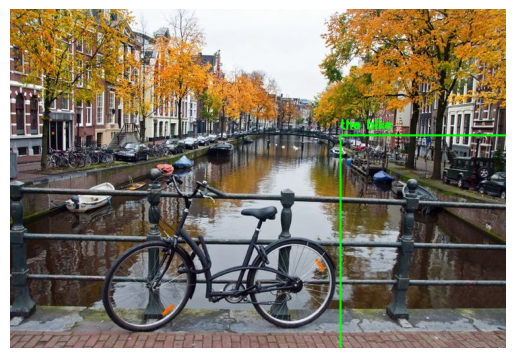

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL → OpenCV (RGB → BGR)
cv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# We are using the bboxes extracted above

# Draw boxes
for item in bboxes:
    x1, y1, x2, y2 = item["box_2d"]
    label = item["label"]

    cv2.rectangle(cv_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        cv_image,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Convert back to RGB for display
rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

# Show in notebook
plt.imshow(rgb_image)
plt.axis("off")

# Preliminary conclusions


We tested Gemma 4:E2B on CPU for text, image and object detection. 

Both text (including multi-language) and image tests proved great performance. When asked to answer to a question in a foreign language, without being instructed to answer shortly, the model took long time to generate a long text sequence.

For object detection, the performance of the Gemma 4:E2B model is moderate, as it is shown as well in the tests on HuggingFace. We will conduct the similar test with the next size model as well (in another Notebook).
